# Задача 1.  

In [38]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt

rnd = np.random.RandomState(42)



Приведите пример матрицы, для которой QR-алгоритм не сходится.

## Ответ

$$
A = \begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$

### Доказательство:

Матрица $A$ является ортогональной: $A^T = A$ и $A^T A = I$. Её собственные значения: $\lambda_1 = 1$, $\lambda_2 = -1$.

Проведем итерационный процесс QR разложения:
1. $A = Q_0 R_0$, где $Q_0 = A$ (ортогональная), $R_0 = I$.
2. $A_1 = R_0 Q_0 = I \cdot A = A$.

Таким образом, $A_k = A$ для всех $k$, и последовательность не сходится к треугольной матрице.




# Задача 2

Реализуйте метод итераций для решения системы линейных уравнений (метод Якоби). Для этого перепишите уравнение $A x=b$, выделив диагональную часть матрицы $A:$
$$
A=D+(A-D) \text {, }
$$
в виде
$$
x_{n+1}=B x_{n}+c
$$
где $B=D^{-1}(D-A) .$ 

Найдите $c . $ 
Создавайте случайную матрицу с диагональным доминированием следующим способом:

n=10

A = rnd.uniform (size=(n,n))+np.diag([15]*n)

b = rnd.uniform (size=n)

Вычислите норму L2 (евклидову) соответствующей матрицы $B$ и выполните 22 итерации метода Якоби, распечатывая вектор х через каждые три итерации. В качестве начального приближения возьмите вектор из единиц. Убедитесь, что результируюший вектор $x$ действительно решает исходную систему.
Матрица $A$, с которой вы работали выше, по построению доминируется диагональю. Что произойдёт, если уменьшать величину диагональных элементов? Проверьте сходимость итераций Якоби (вычислите также норму матрицы $B$ ).


In [39]:
n=10
A = rnd.uniform(size=(n,n))+np.diag([15]*n)
b = rnd.uniform(size=n)

D = np.diag(np.diag(A))
D_inv = np.diag(1.0 / np.diag(A))
B = D_inv @ (D - A)
c = D_inv @ b

norm_B = LA.norm(B, 2)
print(f"Норма матрицы B: {norm_B:.6f}")

x = np.ones(n)
for k in range(22):
    x = B @ x + c
    if (k + 1) % 3 == 0:
        print(f"Итерация {k+1}: {x}")

x_exact = LA.solve(A, b)
print(f"Проверка: ||Ax - b|| = {LA.norm(A @ x - b):.2e}")

diag_values = [15, 10, 5, 2, 1, 0.5]
for d in diag_values:
    A_test = rnd.uniform(size=(n,n)) + np.diag([d]*n)
    D_test = np.diag(np.diag(A_test))
    D_inv_test = np.diag(1.0 / np.diag(A_test))
    B_test = D_inv_test @ (D_test - A_test)
    norm_B_test = LA.norm(B_test, 2)
    print(f"Диагональ = {d:4.1f}, ||B|| = {norm_B_test:.6f}")

Норма матрицы B: 0.276822
Итерация 3: [-0.02705665  0.02217622 -0.00250182  0.00798258  0.03615409 -0.01170303
 -0.00011122  0.02236134 -0.01100527 -0.02352191]
Итерация 6: [-0.00494443  0.03619319  0.01597125  0.02731041  0.0544467   0.00956431
  0.02204662  0.04462412  0.0093377  -0.00301904]
Итерация 9: [-0.00538276  0.03591597  0.01560442  0.02692554  0.05408438  0.00914174
  0.02160657  0.04418184  0.00893275 -0.00342549]
Итерация 12: [-0.00537406  0.03592148  0.01561171  0.02693318  0.05409158  0.00915013
  0.02161531  0.04419062  0.00894079 -0.00341742]
Итерация 15: [-0.00537423  0.03592137  0.01561156  0.02693303  0.05409143  0.00914996
  0.02161514  0.04419045  0.00894063 -0.00341758]
Итерация 18: [-0.00537423  0.03592137  0.01561157  0.02693303  0.05409144  0.00914996
  0.02161514  0.04419045  0.00894063 -0.00341758]
Итерация 21: [-0.00537423  0.03592137  0.01561157  0.02693303  0.05409144  0.00914996
  0.02161514  0.04419045  0.00894063 -0.00341758]
Проверка: ||Ax - b|| = 2.

# Задача 3

Рассмотрите диагональную матрицу $D$ размера $n \times n$ и вектор-столбец $u$. Выберите $D$ и $u$ случайным образом (сгенерировав их элементы из стандартного нормального распределения) и найдите минимальное собственное значение и соответствующий собственный ему собственный вектор матрицы
$$
A=D+\frac{u u^{T}}{u^{T} u}
$$

Рассмотрите случай $n=10^{2}$

In [40]:
n = 100
D = np.diag(rnd.standard_normal(n))
u = rnd.standard_normal(n)
A = D + np.outer(u, u) / np.dot(u, u)

eigenvals, eigenvecs = LA.eig(A)
idx_min = np.argmin(eigenvals.real)
lambda_min = eigenvals[idx_min].real
v_min = eigenvecs[:, idx_min].real

print(f"Минимальное собственное значение: {lambda_min:.6f}")
print(f"Соответствующий собственный вектор (первые 5 компонент): {v_min[:5]}")


Минимальное собственное значение: -2.471273
Соответствующий собственный вектор (первые 5 компонент): [ 1.30632559e-04  5.80158162e-04 -9.99935069e-01  2.45984402e-04
  1.33609376e-03]


Решите задачу 3 для случая $n=10^{4}$. Для этого используйте  Вunch-Nielsen-Sorensen formula.


Пусть $\lambda_{i}$ обозначают собственные значения матрицы $A$, а $\widetilde{\lambda}_{i}$ обозначают собственные значения обновлённой матрицы $\widetilde{A}=A+v v^{T}$. В частном случае, когда $A$ является диагональной, собственные векторы $\widetilde{q}_{i}$ матрицы $\widetilde{A}$ можно записать в виде

$$
\left(\widetilde{q}_{i}\right)_{k}=\frac{N_{i} v_{k}}{\lambda_{k}-\widetilde{\lambda}_{i}},
$$

где $N_{i}$ -- число, обеспечивающее нормировку вектора $\widetilde{q}_{i}$.

In [41]:
from scipy.sparse.linalg import eigs

n = 10000
D = np.diag(rnd.standard_normal(n))
u = rnd.standard_normal(n)
v = u / np.sqrt(np.dot(u, u))

A_tilde = D + np.outer(v, v)

lambda_min_tilde, _ = eigs(A_tilde, k=1, which='SR')
lambda_min_tilde = lambda_min_tilde[0].real

def bns_eigenvector(lambda_orig, v, lambda_tilde):
    n = len(lambda_orig)
    q = np.zeros(n)
    for k in range(n):
        lambda_k = lambda_orig[k]
        if abs(lambda_k - lambda_tilde) > 1e-14:
            q[k] = v[k] / (lambda_k - lambda_tilde)
        else:
            q[k] = 0.0
    
    norm_q = np.sqrt(np.dot(q, q))
    if norm_q > 1e-14:
        N_i = 1.0 / norm_q
        q = q * N_i
    return q

lambda_orig = np.diag(D)
v_min_bns = bns_eigenvector(lambda_orig, v, lambda_min_tilde)

print(f"Минимальное собственное значение: {lambda_min_tilde:.6f}")


Минимальное собственное значение: -3.922293


# Задача 4

Реализуйте ортогонализацию Грамма-Шмидта. Проверьте насколько матрицы ортогональны на примере матрицы Гильберта. Объясните результаты, сравните с ортогонализацией с помощью отражений Хаусхолдера.


In [42]:
from scipy.linalg import hilbert
from scipy.linalg import qr as householder_qr

def gram_schmidt(A):
    m, n = A.shape
    Q = np.zeros_like(A, dtype=float)
    R = np.zeros((n, n), dtype=float)
    
    for j in range(n):
        v = A[:, j].copy()
        for i in range(j):
            R[i, j] = np.dot(Q[:, i], A[:, j])
            v -= R[i, j] * Q[:, i]
        R[j, j] = np.linalg.norm(v)
        if R[j, j] > 1e-14:
            Q[:, j] = v / R[j, j]
        else:
            Q[:, j] = v
    
    return Q, R

n = 10
H = hilbert(n)

Q_gs, R_gs = gram_schmidt(H)
Q_hh, R_hh = householder_qr(H, mode='economic')

orthogonality_gs = np.linalg.norm(Q_gs.T @ Q_gs - np.eye(n))
orthogonality_hh = np.linalg.norm(Q_hh.T @ Q_hh - np.eye(n))

print(f"Ортогональность (Грамм-Шмидт): {orthogonality_gs:.2e}")
print(f"Ортогональность (Хаусхолдер): {orthogonality_hh:.2e}")


Ортогональность (Грамм-Шмидт): 3.47e+00
Ортогональность (Хаусхолдер): 1.50e-15



# Задача 5

Для системы линейных алгебраических уравнений
$$
\
A = \begin{pmatrix}
5 & -1 & 2 \\
1 & 4 & -1 \\
1 & 1 & 1
\end{pmatrix}, \quad 
f = \begin{pmatrix}
8 \\ -4 \\ 4
\end{pmatrix}
\
$$
построить итерационный метод Зейделя. Найти первое и второе приближения по методу Зейделя, задав в качестве начального приближения нулевой вектор. Доказать сходимость метода.


In [43]:
A = np.array([[5, -1, 2],
              [1, 4, -1],
              [1, 1, 1]], dtype=float)
f = np.array([8, -4, 4], dtype=float)

L = np.tril(A, -1)
D = np.diag(np.diag(A))
U = np.triu(A, 1)

DL_inv = np.linalg.inv(D + L)
B_seidel = -DL_inv @ U
c_seidel = DL_inv @ f

x0 = np.zeros(3)
x1 = B_seidel @ x0 + c_seidel
x2 = B_seidel @ x1 + c_seidel

print(f"Первое приближение: {x1}")
print(f"Второе приближение: {x2}")

norm_B_seidel = np.linalg.norm(B_seidel, 2)


Первое приближение: [ 1.6 -1.4  3.8]
Второе приближение: [-0.2  0.   4.2]


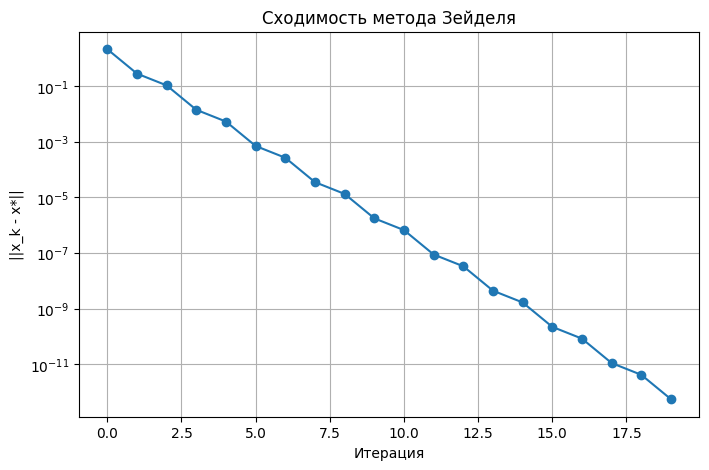

In [44]:
x_exact = np.linalg.solve(A, f)
x = np.zeros(3)
errors = []
iterations = list(range(20))

for k in iterations:
    x = B_seidel @ x + c_seidel
    errors.append(np.linalg.norm(x - x_exact))

plt.figure(figsize=(8, 5))
plt.semilogy(iterations, errors, marker='o')
plt.xlabel('Итерация')
plt.ylabel('||x_k - x*||')
plt.title('Сходимость метода Зейделя')
plt.grid(True)
plt.show()


# Задача 6 *.  Спектры.

Постройте псевдоспектр матрицы 20-го порядка

$$A=\left[\begin{array}{rrrrrrr}
20 & 20 & 0 & 0 & \ldots & 0 & 0 \\
0 & 19 & 20 & 0 & \ldots & 0 & 0 \\
0 & 0 & 18 & 20 & \ldots & 0 & 0 \\
\ldots & \ldots & \ldots & \ldots & \ldots & . \\
0 & 0 & 0 & 0 & \ldots & 2 & 20 \\
\boldsymbol{\varepsilon} & 0 & 0 & 0 & \ldots & 0 & 1
\end{array}\right]$$

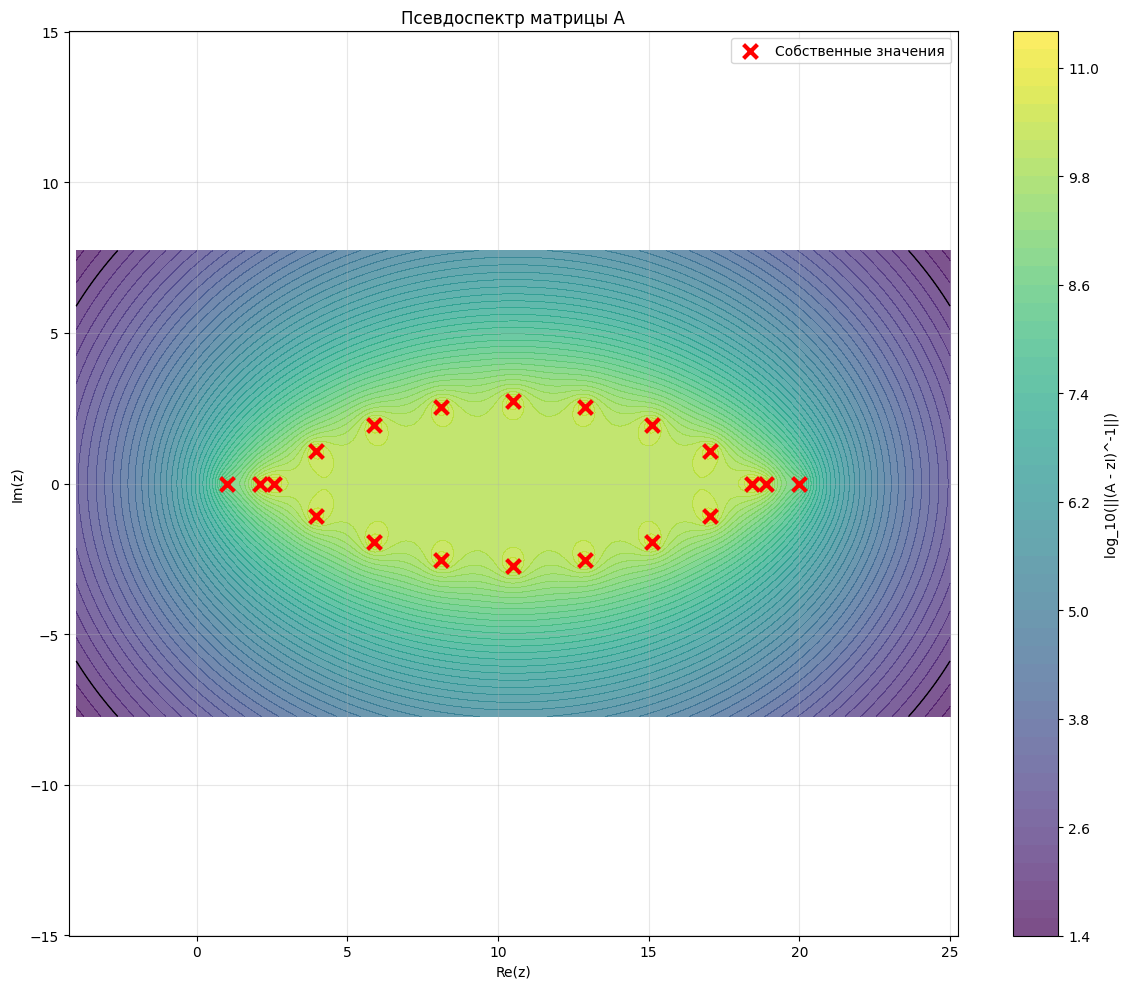

In [45]:
n = 20
eps = 1e-10
A = np.zeros((n, n))

for i in range(n):
    A[i, i] = n - i
    if i < n - 1:
        A[i, i+1] = 20
A[n-1, 0] = eps

eigenvals = np.linalg.eigvals(A)

x_min, x_max = eigenvals.real.min() - 5, eigenvals.real.max() + 5
y_min, y_max = eigenvals.imag.min() - 5, eigenvals.imag.max() + 5

nx, ny = 200, 200
x = np.linspace(x_min, x_max, nx)
y = np.linspace(y_min, y_max, ny)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

pseudospec = np.zeros((ny, nx))
I = np.eye(n)

for i in range(ny):
    for j in range(nx):
        z = Z[i, j]
        try:
            resolvent = A - z * I
            s = np.linalg.svd(resolvent, compute_uv=False)
            sigma_min = s[-1]
            if sigma_min > 1e-14:
                pseudospec[i, j] = 1.0 / sigma_min
            else:
                pseudospec[i, j] = 1e14
        except:
            pseudospec[i, j] = 1e14

levels = [1e-8, 1e-6, 1e-4, 1e-2, 1e-1, 1e0, 1e1, 1e2]

plt.figure(figsize=(12, 10))
contour = plt.contour(X, Y, np.log10(pseudospec + 1e-16), levels=np.log10(levels), colors='black', linewidths=1)
plt.contourf(X, Y, np.log10(pseudospec + 1e-16), levels=50, cmap='viridis', alpha=0.7)
plt.colorbar(label=fr'log_10(||(A - zI)^{-1}||)')
plt.scatter(eigenvals.real, eigenvals.imag, c='red', s=100, marker='x', linewidths=3, label='Собственные значения', zorder=5)
plt.xlabel(r'Re(z)')
plt.ylabel(r'Im(z)')
plt.title('Псевдоспектр матрицы A')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.tight_layout()
plt.show()
